In [6]:
import numpy as np
from numpy.typing import ArrayLike, NDArray
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def rollout_concentration_metrics(
    R: ArrayLike,
    *,
    check_stochastic: bool = True,
    atol: float = 1e-10,
) -> dict[str, float | NDArray[np.float64]]:
    """
    Compute the Dobrushin coefficient of a global rollout matrix R,
    its rank-one approximation Pi_R, and ||R - Pi_R||_{infinity,1}.

    Definitions
    -----------
    kappa(R) = 0.5 * max_{i,k} sum_j |R[i,j] - R[k,j]|

    v = (1/d) * R.T @ 1

    Pi_R = 1 @ v.T

    ||R - Pi_R||_{infinity,1}
        = max_i sum_j |R[i,j] - Pi_R[i,j]|

    Parameters
    ----------
    R:
        Square global rollout matrix.
    check_stochastic:
        Check that R is nonnegative and row-stochastic.
    atol:
        Numerical tolerance used in the checks.

    Returns
    -------
    Dictionary containing:
        - "dobrushin_coefficient"
        - "v"
        - "Pi_R"
        - "error_inf_1"
        - "theoretical_bound"
        - "bound_satisfied"
    """
    R = np.asarray(R, dtype=np.float64)

    if R.ndim != 2 or R.shape[0] != R.shape[1]:
        raise ValueError(
            f"R must be a square two-dimensional array; received shape {R.shape}."
        )

    if not np.all(np.isfinite(R)):
        raise ValueError("R contains NaN or infinite values.")

    d = R.shape[0]

    if check_stochastic:
        if np.any(R < -atol):
            raise ValueError("R contains negative entries beyond numerical tolerance.")

        row_sums = R.sum(axis=1)        
        # if not np.allclose(row_sums, 1.0, atol=atol, rtol=0.0):
        #     max_error = np.max(np.abs(row_sums - 1.0))
        #     raise ValueError(
        #         "R is not row-stochastic. "
        #         f"Maximum row-sum error is {max_error:.3e}."
        #     )

    # Pairwise L1 distances between the rows:
    # row_distances[i, k] = sum_j |R[i,j] - R[k,j]|.
    row_distances = np.abs(R[:, None, :] - R[None, :, :]).sum(axis=2)

    kappa = 0.5 * np.max(row_distances)

    # Common row profile of the rank-one approximation.
    v = R.mean(axis=0)

    # Every row of Pi_R equals v.
    Pi_R = np.broadcast_to(v, R.shape).copy()

    # Maximum row-wise L1 error.
    error_inf_1 = np.max(np.abs(R - Pi_R).sum(axis=1))

    theoretical_bound = 2.0 * kappa

    return {
        "dobrushin_coefficient": float(kappa),
        "v": v,
        "Pi_R": Pi_R,
        "error_inf_1": float(error_inf_1),
        "theoretical_bound": float(theoretical_bound),
        "bound_satisfied": bool(error_inf_1 <= theoretical_bound + atol),
    }

### Trained models

In [26]:
NUM_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20] 
SEEDS = [12, 123, 1234]
dobrushin = []
error = []

dobrushin_dict = {}
error_dict = {}
v_dict = {}


for seed in SEEDS:
    dobrushin = []
    error = []
    v = []
    ROLL = Path(f"Results/rollout_global/seed_{seed}")
    for l in NUM_LAYERS:
        rollout = np.load(ROLL / f"{l}layers/rollout{l}layers.npz")
        R = rollout["rollout"]
        results = rollout_concentration_metrics(R)
        dobrushin.append(results["dobrushin_coefficient"])
        error.append(results["error_inf_1"])        
        v.append(results["v"])

    dobrushin_dict[seed] = dobrushin
    error_dict[seed] = error    
    v_dict[seed] = v

### Untrained models

In [27]:
dobrushin_dict_un = {}
error_dict_un = {}
v_dict_un = {}

for seed in SEEDS:
    dobrushin_un = []
    error_un = []
    v_un = []
    ROLL = Path(f"Results/rollout_global/seed_{seed}")
    for l in NUM_LAYERS:
        rollout = np.load(ROLL / f"{l}layers/rollout{l}layers_untrained.npz")
        R = rollout["rollout"]
        results = rollout_concentration_metrics(R)
        dobrushin_un.append(results["dobrushin_coefficient"])
        error_un.append(results["error_inf_1"])        
        v_un.append(results["v"])

    dobrushin_dict_un[seed] = dobrushin_un
    error_dict_un[seed] = error_un
    v_dict_un[seed] = v_un

In [10]:
def mean_and_std_across_seeds(
    values_by_seed: dict,
    expected_length: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the pointwise mean and standard deviation across random seeds.

    Each dictionary value must contain one value per Transformer depth.
    """
    values = np.asarray([values_by_seed[seed] for seed in sorted(values_by_seed)], dtype=float)

    if values.ndim != 2:
        raise ValueError("Each dictionary value must be a one-dimensional sequence.")

    if values.shape[1] != expected_length:
        raise ValueError(f"Expected {expected_length} values per seed, " 
                         f"but found {values.shape[1]}.")

    mean = np.mean(values, axis=0)
    std = np.std(values, axis=0, ddof=1)

    return mean, std

dobrushin_mean, dobrushin_std = mean_and_std_across_seeds(dobrushin_dict, 
                                                          expected_length=len(NUM_LAYERS))

error_mean, error_std = mean_and_std_across_seeds(error_dict, expected_length=len(NUM_LAYERS))

dobrushin_mean_un, dobrushin_std_un = mean_and_std_across_seeds(dobrushin_dict_un, 
                                                                expected_length=len(NUM_LAYERS))

error_mean_un, error_std_un = mean_and_std_across_seeds(error_dict_un, 
                                                        expected_length=len(NUM_LAYERS))

In [19]:
import numpy as np
from itertools import combinations, product
from scipy.stats import spearmanr


def validate_profile(v: np.ndarray, atol: float = 1e-8) -> np.ndarray:
    """
    Convert a profile to a one-dimensional probability vector
    and check that it is valid.
    """
    v = np.asarray(v, dtype=float).reshape(-1)

    if np.any(v < -atol):
        raise ValueError("Profiles must have non-negative entries.")

    v = np.clip(v, 0.0, None)

    if not np.isclose(v.sum(), 1.0, atol=atol):
        raise ValueError(f"Profile does not sum to 1. Current sum: {v.sum():.8f}")

    return v


def profile_distance(v1: np.ndarray,
                     v2: np.ndarray,
                     metric: str = "tv") -> float:
    """
    Distance between two probability profiles.

    Supported metrics:
        'tv'   : total variation distance = 0.5 * ||v1-v2||_1
        'l1'   : L1 distance
        'l2'   : Euclidean distance
        'linf' : maximum absolute difference
        'js'   : Jensen-Shannon distance
    """
    v1 = validate_profile(v1)
    v2 = validate_profile(v2)

    if v1.shape != v2.shape:
        raise ValueError("The two profiles must have the same dimension.")

    diff = v1 - v2

    if metric == "tv":
        return 0.5 * np.linalg.norm(diff, ord=1)

    if metric == "l1":
        return np.linalg.norm(diff, ord=1)

    if metric == "l2":
        return np.linalg.norm(diff, ord=2)

    if metric == "linf":
        return np.linalg.norm(diff, ord=np.inf)

    if metric == "js":
        # Jensen-Shannon distance: sqrt(JS divergence)
        m = 0.5 * (v1 + v2)

        def kl_divergence(p, q):
            mask = p > 0
            return np.sum(p[mask] * np.log(p[mask] / q[mask]))

        js_divergence = 0.5 * (kl_divergence(v1, m) + kl_divergence(v2, m))
        return np.sqrt(js_divergence)

    raise ValueError("Unknown metric. Choose from: 'tv', 'l1', 'l2', 'linf', 'js'.")

In [20]:
def matched_seed_distances(trained_profiles: dict,
                           untrained_profiles: dict,
                           depths: list,
                           metric: str = "tv") -> dict:
    """
    Compute the trained-untrained profile distance at each depth,
    matching runs with the same seed.

    Returns
    -------
    results[depth] = {
        'per_seed': {seed: distance},
        'mean': ...,
        'std': ...
    }
    """
    common_seeds = sorted(set(trained_profiles).intersection(untrained_profiles))

    if not common_seeds:
        raise ValueError("The trained and untrained dictionaries have no common seeds.")

    results = {}

    for depth_idx, depth in enumerate(depths):
        per_seed = {}

        for seed in common_seeds:
            v_trained = trained_profiles[seed][depth_idx]
            v_untrained = untrained_profiles[seed][depth_idx]

            per_seed[seed] = profile_distance(v_trained, v_untrained, metric=metric)

        values = np.asarray(list(per_seed.values()))

        results[depth] = {"per_seed": per_seed, 
                          "mean": values.mean(),
                          "std": values.std(ddof=1) if len(values) > 1 else 0.0}

    return results

In [31]:
matched_results = matched_seed_distances(v_dict, v_dict_un, 
                                         depths=NUM_LAYERS, 
                                         metric="l1")

for depth in NUM_LAYERS:
    result = matched_results[depth]

    print(
        f"Depth {depth:2d}: "
        f"l1 distance = {result['mean']:.4f} "
        f"± {result['std']:.4f}"
    )

Depth  3: l1 distance = 0.1438 ± 0.0006
Depth  5: l1 distance = 0.1644 ± 0.0280
Depth  7: l1 distance = 0.1529 ± 0.0212
Depth  9: l1 distance = 0.1452 ± 0.0181
Depth 11: l1 distance = 0.1511 ± 0.0038
Depth 13: l1 distance = 0.1489 ± 0.0062
Depth 15: l1 distance = 0.1618 ± 0.0164
Depth 17: l1 distance = 0.1573 ± 0.0114
Depth 20: l1 distance = 0.1318 ± 0.0087


In [32]:
import numpy as np
from itertools import combinations, product


def l1_distance(v1, v2):
    """L1 distance between two profile vectors."""
    v1 = np.asarray(v1, dtype=float).reshape(-1)
    v2 = np.asarray(v2, dtype=float).reshape(-1)

    if v1.shape != v2.shape:
        raise ValueError("Profiles must have the same dimension.")

    return np.linalg.norm(v1 - v2, ord=1)


def compare_within_between_distances(trained_profiles, 
                                     untrained_profiles, 
                                     depths):
    """
    Compare, at each depth:

    1. trained vs untrained distances:
       ||v_trained(seed_i) - v_untrained(seed_j)||_1

    2. within-trained distances:
       ||v_trained(seed_i) - v_trained(seed_j)||_1

    3. within-untrained distances:
       ||v_untrained(seed_i) - v_untrained(seed_j)||_1

    Parameters
    ----------
    trained_profiles : dict
        Keys are seeds. Values are lists of profile vectors,
        ordered according to `depths`.

    untrained_profiles : dict
        Same structure as trained_profiles.

    depths : list
        Transformer depths in the same order as the profile lists.

    Returns
    -------
    results : dict
        Results indexed by depth.
    """
    trained_seeds = sorted(trained_profiles.keys())
    untrained_seeds = sorted(untrained_profiles.keys())

    results = {}

    for depth_idx, depth in enumerate(depths):

        # All trained-untrained pairs
        between_distances = []

        for trained_seed, untrained_seed in product(trained_seeds, untrained_seeds):
            v_trained = trained_profiles[trained_seed][depth_idx]
            v_untrained = untrained_profiles[untrained_seed][depth_idx]

            between_distances.append(l1_distance(v_trained, v_untrained))

        # All distinct pairs of trained seeds
        within_trained_distances = []

        for seed_1, seed_2 in combinations(trained_seeds, 2):
            v_1 = trained_profiles[seed_1][depth_idx]
            v_2 = trained_profiles[seed_2][depth_idx]

            within_trained_distances.append(l1_distance(v_1, v_2))

        # All distinct pairs of untrained seeds
        within_untrained_distances = []

        for seed_1, seed_2 in combinations(untrained_seeds, 2):
            v_1 = untrained_profiles[seed_1][depth_idx]
            v_2 = untrained_profiles[seed_2][depth_idx]

            within_untrained_distances.append(l1_distance(v_1, v_2))

        between_distances = np.asarray(between_distances)
        within_trained_distances = np.asarray(within_trained_distances)
        within_untrained_distances = np.asarray(within_untrained_distances)

        results[depth] = {"between_values": between_distances,
                          "within_trained_values": within_trained_distances,
                          "within_untrained_values": within_untrained_distances,
                          "between_mean": np.mean(between_distances),
                          "between_std": np.std(between_distances, ddof=1), 
                          "within_trained_mean": np.mean(within_trained_distances),
                          "within_trained_std": np.std(within_trained_distances, ddof=1),
                          "within_untrained_mean": np.mean(within_untrained_distances), 
                          "within_untrained_std": np.std(within_untrained_distances, ddof=1)
                         }

    return results

In [33]:
results = compare_within_between_distances(v_dict, v_dict_un, NUM_LAYERS)

for depth in NUM_LAYERS:
    r = results[depth]

    print(
        f"Depth {depth:2d} | "
        f"Trained-untrained: "
        f"{r['between_mean']:.4f} ± {r['between_std']:.4f} | "
        f"Within trained: "
        f"{r['within_trained_mean']:.4f} ± "
        f"{r['within_trained_std']:.4f} | "
        f"Within untrained: "
        f"{r['within_untrained_mean']:.4f} ± "
        f"{r['within_untrained_std']:.4f}"
    )

Depth  3 | Trained-untrained: 0.1434 ± 0.0018 | Within trained: 0.0545 ± 0.0472 | Within untrained: 0.0247 ± 0.0028
Depth  5 | Trained-untrained: 0.1643 ± 0.0269 | Within trained: 0.1190 ± 0.0202 | Within untrained: 0.0249 ± 0.0028
Depth  7 | Trained-untrained: 0.1526 ± 0.0180 | Within trained: 0.1029 ± 0.0083 | Within untrained: 0.0248 ± 0.0029
Depth  9 | Trained-untrained: 0.1454 ± 0.0163 | Within trained: 0.0946 ± 0.0098 | Within untrained: 0.0248 ± 0.0029
Depth 11 | Trained-untrained: 0.1518 ± 0.0025 | Within trained: 0.0952 ± 0.0082 | Within untrained: 0.0248 ± 0.0029
Depth 13 | Trained-untrained: 0.1484 ± 0.0062 | Within trained: 0.1033 ± 0.0081 | Within untrained: 0.0248 ± 0.0029
Depth 15 | Trained-untrained: 0.1621 ± 0.0147 | Within trained: 0.0793 ± 0.0686 | Within untrained: 0.0248 ± 0.0029
Depth 17 | Trained-untrained: 0.1568 ± 0.0085 | Within trained: 0.0846 ± 0.0070 | Within untrained: 0.0248 ± 0.0029
Depth 20 | Trained-untrained: 0.1316 ± 0.0064 | Within trained: 0.0874 ±

In [48]:
def distance_from_uniform(v, metric="l1"):
    v = np.asarray(v, dtype=float).reshape(-1)
    uniform = np.ones_like(v) / len(v)

    if metric == "l1":
        return np.linalg.norm(v - uniform, ord=1)

    if metric == "tv":
        return 0.5 * np.linalg.norm(v - uniform, ord=1)

    if metric == "l2":
        return np.linalg.norm(v - uniform, ord=2)

    raise ValueError("metric must be 'l1', 'tv', or 'l2'")

In [52]:
metric = "l1"

trained_uniform_results = {}
untrained_uniform_results = {}

for depth_idx, depth in enumerate(NUM_LAYERS):

    trained_distances = np.array([distance_from_uniform(v_dict[seed][depth_idx], 
                                                        metric=metric) 
                                  for seed in v_dict])

    untrained_distances = np.array([distance_from_uniform(v_dict_un[seed][depth_idx], 
                                                          metric=metric) 
                                    for seed in v_dict_un])

    trained_uniform_results[depth] = {"values": trained_distances,
                                      "mean": trained_distances.mean(),
                                      "std": trained_distances.std(ddof=1)}

    untrained_uniform_results[depth] = {"values": untrained_distances, 
                                        "mean": untrained_distances.mean(), 
                                        "std": untrained_distances.std(ddof=1)}

In [53]:
for depth in NUM_LAYERS:
    trained_result = trained_uniform_results[depth]
    untrained_result = untrained_uniform_results[depth]

    print(
        f"Depth {depth:2d} | "
        f"Trained vs uniform: "
        f"{trained_result['mean']:.4f} ± "
        f"{trained_result['std']:.4f} | "
        f"Untrained vs uniform: "
        f"{untrained_result['mean']:.4f} ± "
        f"{untrained_result['std']:.4f}"
    )

Depth  3 | Trained vs uniform: 0.1434 ± 0.0015 | Untrained vs uniform: 0.0183 ± 0.0015
Depth  5 | Trained vs uniform: 0.1616 ± 0.0308 | Untrained vs uniform: 0.0183 ± 0.0015
Depth  7 | Trained vs uniform: 0.1506 ± 0.0201 | Untrained vs uniform: 0.0183 ± 0.0015
Depth  9 | Trained vs uniform: 0.1428 ± 0.0188 | Untrained vs uniform: 0.0183 ± 0.0015
Depth 11 | Trained vs uniform: 0.1511 ± 0.0022 | Untrained vs uniform: 0.0183 ± 0.0015
Depth 13 | Trained vs uniform: 0.1469 ± 0.0063 | Untrained vs uniform: 0.0183 ± 0.0015
Depth 15 | Trained vs uniform: 0.1606 ± 0.0168 | Untrained vs uniform: 0.0183 ± 0.0015
Depth 17 | Trained vs uniform: 0.1553 ± 0.0097 | Untrained vs uniform: 0.0183 ± 0.0015
Depth 20 | Trained vs uniform: 0.1314 ± 0.0073 | Untrained vs uniform: 0.0183 ± 0.0015


### Plot

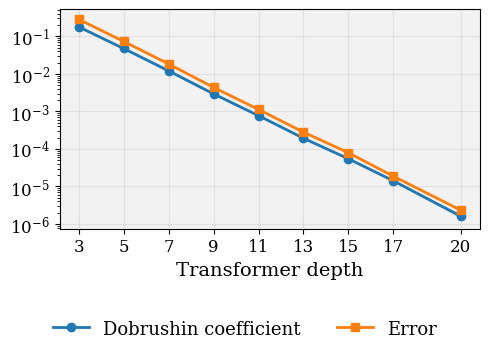

In [55]:
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(NUM_LAYERS, dobrushin_mean, marker="o", linewidth=2, 
        label="Dobrushin coefficient")

ax.fill_between(NUM_LAYERS, 
                dobrushin_mean - dobrushin_std, 
                dobrushin_mean + dobrushin_std, 
                alpha=0.2)

ax.plot(NUM_LAYERS, error_mean, marker="s", linewidth=2, 
        label="Error")

ax.fill_between(NUM_LAYERS, 
                error_mean - error_std, 
                error_mean + error_std,
                alpha=0.2)

ax.set_yscale("log")

ax.set_xlabel("Transformer depth", fontsize=14)
# ax.set_ylabel(r"Mean $\pm$ standard deviation", fontsize=14)

ax.set_xticks(NUM_LAYERS)
ax.tick_params(axis="both", labelsize=12)

ax.set_facecolor("#f2f2f2")
ax.grid(alpha=0.25)
# ax.legend(fontsize=11)

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    fontsize=13,
    frameon=False
)  

plt.savefig("Results/attention_plots/dobrushin.pdf", bbox_inches="tight")

fig.tight_layout()
plt.show()